# PBQ-02 strict resource validation notebook

Additive notebook only. It preserves the original PBQ-02 practice notebooks and adds the FAQ, data hygiene, and VaR/ES resource coverage in an offline, reproducible form.

## 1. Configure local files

The official resource projects can use live APIs such as yfinance, Gemini, or Mistral. This validation notebook uses only local files so the results are reproducible in the study pack.

In [1]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd

CODE_DIR = Path('.')
TCS_FILE = CODE_DIR / 'TCS.NS.csv'
AXIS_FILE = CODE_DIR / 'AXISBANK_data_hygiene.csv'
print('TCS exists:', TCS_FILE.exists())
print('AXISBANK hygiene file exists:', AXIS_FILE.exists())

TCS exists: True
AXISBANK hygiene file exists: True


## 2. PBQ-02 FAQ examples

These examples make the FAQ distinctions executable without downloading live market data.

In [2]:
sample = pd.DataFrame({'price': [98, 101, 100, 104], 'volume': [900, 1500, 1200, 2100]})
sample['np_where_signal'] = np.where(sample['price'] > 100, 'above_100', 'not_above_100')
where_result = sample.where(sample['volume'] > 1200)
boolean_slice = sample[sample['volume'] > 1200]
sample['three_way_signal'] = np.where(sample['price'] > 102, 1, np.where(sample['price'] < 100, -1, 0))
strategy_config = (20, 50, 'long_only')
print('Immutable tuple config:', strategy_config)
print('Tuple has append method:', hasattr(strategy_config, 'append'))
display(sample)
display(where_result)
display(boolean_slice)

Immutable tuple config: (20, 50, 'long_only')
Tuple has append method: False


,price,volume,np_where_signal,three_way_signal
0,98,900,not_above_100,-1
1,101,1500,above_100,0
2,100,1200,not_above_100,0
3,104,2100,above_100,1


,price,volume,np_where_signal
0,NaN,NaN,NaN
1,101.0,1500.0,above_100
2,NaN,NaN,NaN
3,104.0,2100.0,above_100


,price,volume,np_where_signal
1,101,1500,above_100
3,104,2100,above_100


## 3. Data Hygiene Auditor offline proxy

The official project asks students to upload data, select a ticker, call a trusted market source, and optionally use an AI provider. The offline proxy checks structural issues without calling external services.

In [3]:
axis = pd.read_csv(AXIS_FILE)
axis['Date'] = pd.to_datetime(axis['Date'])
axis = axis.sort_values('Date').set_index('Date')
missing_counts = axis.isna().sum().sort_values(ascending=False)
business_days = pd.bdate_range(axis.index.min(), axis.index.max())
missing_business_days = business_days.difference(axis.index)
ohlc_bad = axis[(axis['High'] < axis[['Open', 'Close', 'Low']].max(axis=1)) | (axis['Low'] > axis[['Open', 'Close', 'High']].min(axis=1))]
large_moves = axis['Close'].pct_change().loc[lambda s: s.abs() > 0.25]
summary = pd.read_csv('pbq02_data_hygiene_summary.csv')
print('Rows:', len(axis))
print('Date range:', axis.index.min().date(), 'to', axis.index.max().date())
print('Business-day proxy gaps:', len(missing_business_days))
print('OHLC violations:', len(ohlc_bad))
print('Large close-to-close moves >25%:', len(large_moves))
display(summary)

Rows: 5306
Date range: 2000-01-03 to 2021-04-30
Business-day proxy gaps: 283
OHLC violations: 0
Large close-to-close moves >25%: 2


,check,result,severity,interpretation
0,rows,5306,info,Number of submitted rows.
1,date_range_start,2000-01-03,info,First date after parsing.
2,date_range_end,2021-04-30,info,Last date after parsing.
3,duplicate_dates,0,pass,Duplicate dates can double-count or overwrite ...
4,missing_business_days_proxy,283,warning,Business-day proxy; exchange holidays require ...
5,ohlc_order_violations,0,pass,High should be at least Open/Close/Low and Low...
6,non_positive_volume,0,pass,Zero or negative volume is suspicious for acti...
7,large_absolute_close_moves_gt_25pct,2,warning,Large close-to-close moves may be real corpora...
8,missing_values_Trades,2850,warning,Trades contains missing values.
9,missing_values_Deliverable Volume,509,warning,Deliverable Volume contains missing values.


## 4. Local TCS returns and distribution diagnostics

The VaR/ES resource starts from returns, not raw prices. The fat-tail diagnostics show why parametric normal VaR is an assumption, not a fact.

In [4]:
tcs = pd.read_csv(TCS_FILE)
tcs['Date'] = pd.to_datetime(tcs['Date'], dayfirst=True)
tcs = tcs.sort_values('Date').set_index('Date')
tcs['daily_returns'] = tcs['Adj Close'].pct_change()
rets = tcs['daily_returns'].dropna()
rets_pct = rets * 100
print('Return observations:', len(rets_pct))
print('Mean daily return (%):', round(rets_pct.mean(), 4))
print('Daily volatility (%):', round(rets_pct.std(ddof=1), 4))
print('Skew:', round(rets_pct.skew(), 4))
print('Excess kurtosis:', round(rets_pct.kurt(), 4))
display(tcs[['Adj Close', 'daily_returns']].head())

Return observations: 1230
Mean daily return (%): 0.0873
Daily volatility (%): 1.6283
Skew: 0.0635
Excess kurtosis: 4.0261


,Adj Close,daily_returns
Date,,
2015-11-18,1038.072876,NaN
2015-11-19,1042.982178,0.004729
2015-11-20,1058.786377,0.015153
2015-11-23,1055.563843,-0.003044
2015-11-24,1045.357300,-0.009669


## 5. Corrected offline VaR and Expected Shortfall

This corrected table fills the earlier continuation blanks without editing that earlier generated file. Shapiro-Wilk is explicitly marked as not run because SciPy is not installed in this workspace.

In [5]:
corrected = pd.read_csv('pbq02_var_es_summary_corrected.csv')
display(corrected)
selected = corrected[corrected['metric'].isin(['historical_var_95_pct', 'historical_cvar_95_pct', 'parametric_var_95_pct', 'parametric_cvar_95_pct', 'monte_carlo_100d_var_95_pct', 'monte_carlo_100d_cvar_95_pct'])]
display(selected[['metric', 'value', 'units']])

,metric,value,units,note
0,observations,1230.0,daily returns,TCS local CSV; first return dropped.
1,mean_daily_return_pct,0.08731832197544384,percent,Arithmetic daily return mean.
2,daily_volatility_pct,1.6282970237472427,percent,Sample standard deviation.
3,skewness,0.06345004287464709,unitless,Pandas sample skew.
4,excess_kurtosis,4.026144151547541,unitless,Pandas excess kurtosis; positive value shows f...
5,shapiro_pvalue_sample_500,not_run_scipy_unavailable,p-value,The official mini-project uses scipy.stats.sha...
6,jarque_bera_stat_approx,831.5794434911869,test statistic,Normality proxy computed from sample skew and ...
7,jarque_bera_pvalue_approx,2.6596115713667143e-181,p-value,Chi-square df=2 survival approximation; near z...
8,historical_var_95_pct,-2.431394646605751,percent return,5th percentile of observed daily returns.
9,historical_cvar_95_pct,-3.613152401792501,percent return,Mean of observed daily returns at or below VaR...


,metric,value,units
8,historical_var_95_pct,-2.431394646605751,percent return
9,historical_cvar_95_pct,-3.613152401792501,percent return
10,parametric_var_95_pct,-2.5909919432894966,percent return
11,parametric_cvar_95_pct,-3.271390803334217,percent return
12,monte_carlo_100d_var_95_pct,-18.269947196568463,percent return
13,monte_carlo_100d_cvar_95_pct,-23.60442130824088,percent return


## 6. Resource map

The added resource bridge connects the FAQ details to data hygiene and risk simulation workflows.

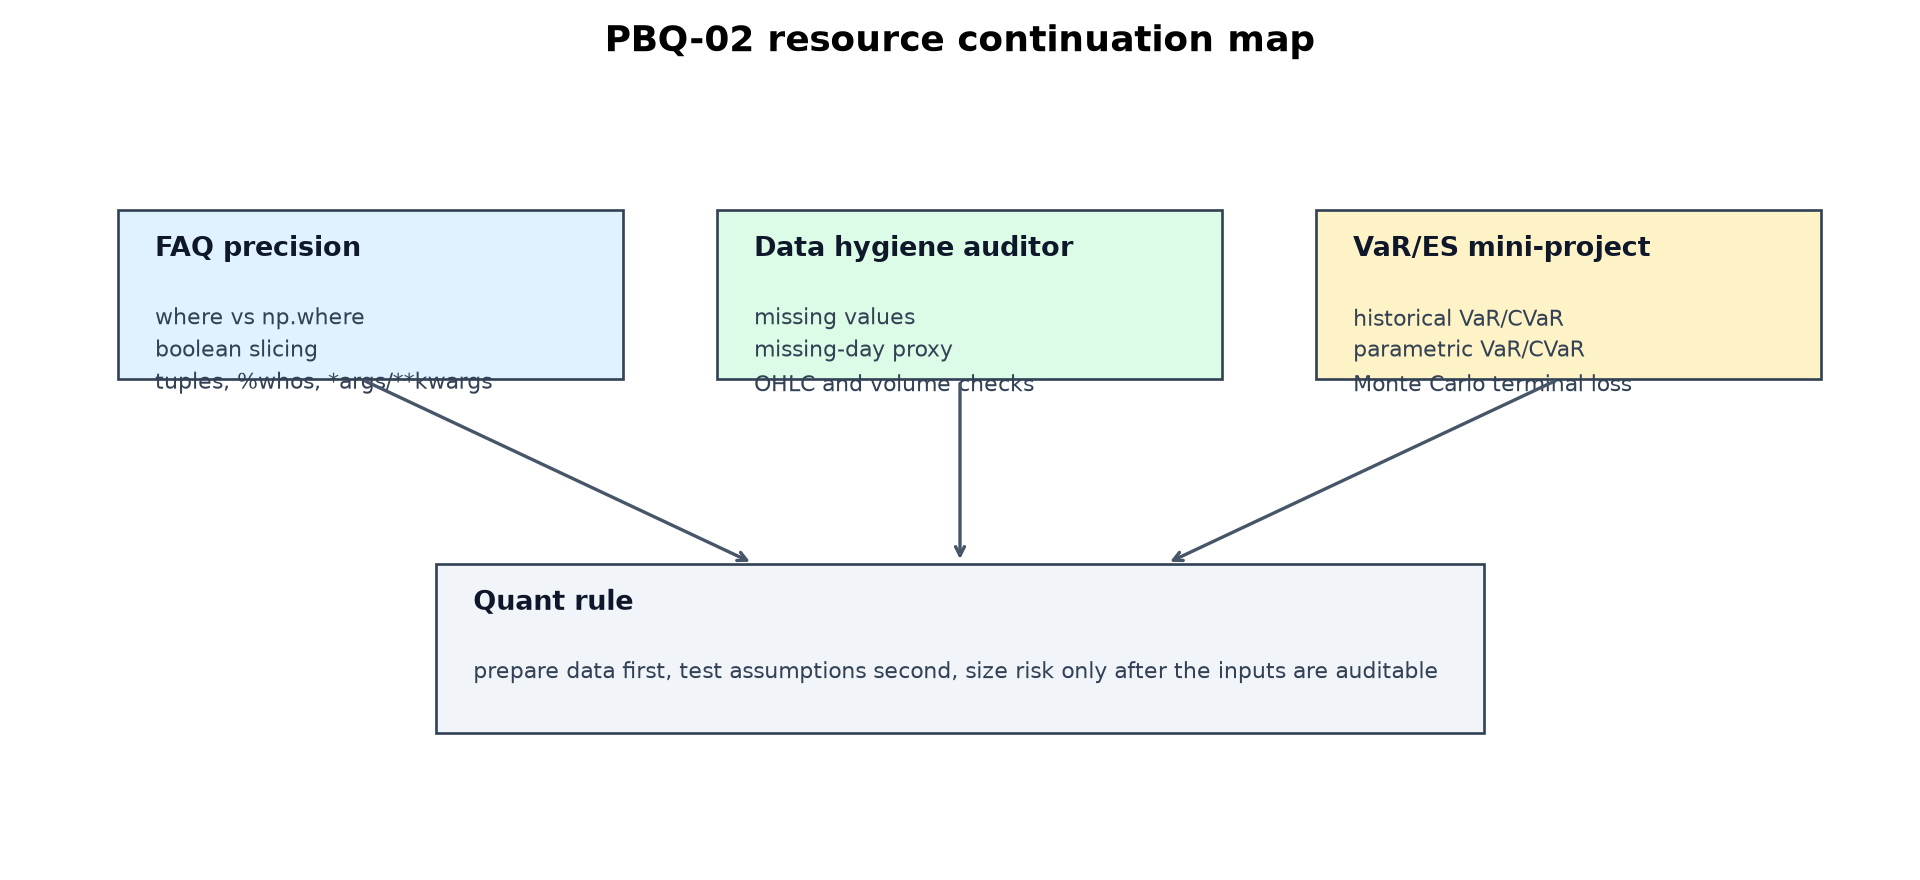

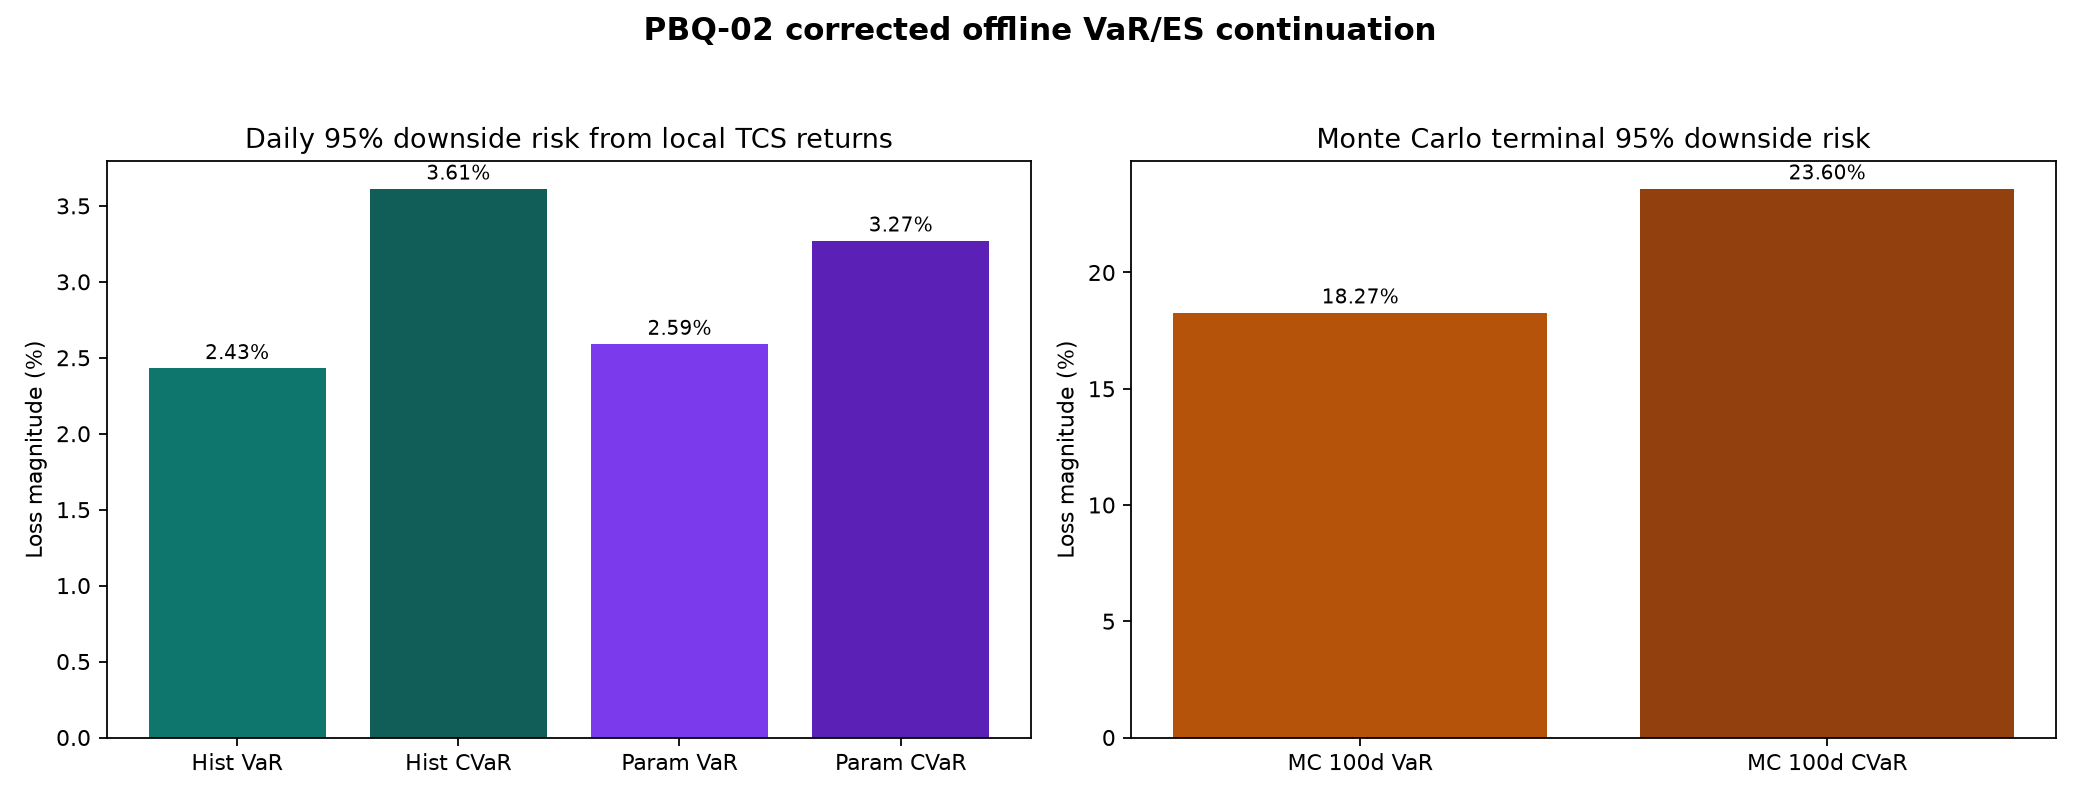

In [6]:
from IPython.display import Image, display
display(Image(filename='chart_continuation_3_pbq02_resource_bridge.png'))
display(Image(filename='chart_continuation_2_pbq02_var_es_corrected.png'))

## 7. Final validation note

All code cells in this notebook are preceded by markdown. The notebook avoids network and API calls, so it can be rerun from the code folder.

In [7]:
print('Strict PBQ-02 continuation complete')

Strict PBQ-02 continuation complete
